# LeetCode #729: My Calendar I

https://leetcode.com/problems/my-calendar-i/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n^2)$ total | $O(n)$ |
| **Optimal: Sorted List + Binary Search ★** | $O(n \log n)$ total | $O(n)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Store all booked intervals in a list. For each new booking, scan the entire list to detect overlaps. $O(n)$ per query, $O(n^2)$ total.

### Optimal: Sorted List + Binary Search ★
Maintain intervals sorted by start time with sentinel endpoints. For each new booking, binary search to find the nearest neighbors. Reject if the predecessor's end exceeds the new start, or the new end exceeds the successor's start. Insertion is $O(\log n)$ lookup + $O(n)$ list shift, making each operation $O(n)$ in the worst case but $O(\log n)$ comparisons.

**Why this is better than Brute Force:** Binary search eliminates unnecessary comparisons — only the immediate neighbors need to be checked for overlap.

**Constraints:**
* At most $10^3$ calls to `book`
* $0 \le \text{start} < \text{end} \le 10^9$


## Solutions

### C#

In [ ]:
public class MyCalendar {
    // Sorted list of (start, end) pairs with sentinel endpoints
    private SortedList<int, int> calendar = new SortedList<int, int>();
    public MyCalendar() { calendar[-1] = -1; calendar[int.MaxValue] = int.MaxValue; }
    public bool Book(int start, int end) {
        // Find index of first key >= start
        int idx = calendar.IndexOfKey(calendar.Keys.FirstOrDefault(k => k >= start, int.MaxValue));
        // Previous booking's end must not exceed start; new end must not exceed next booking's start
        int prevEnd   = calendar.Values[idx > 0 ? idx - 1 : 0];
        int nextStart = calendar.Keys[idx];
        if (prevEnd <= start && end <= nextStart) { calendar[start] = end; return true; }
        return false;
    }
}

### Python

In [ ]:
import bisect

class MyCalendar:
    def __init__(self):
        # Sentinels simplify boundary checks for the first and last intervals
        self.starts = [-1, float('inf')]
        self.ends   = [-1, float('inf')]

    def book(self, start: int, end: int) -> bool:
        # Find insertion point: first start >= new start
        idx = bisect.bisect_right(self.starts, start)
        # Previous booking's end must not exceed start; end must not exceed next booking's start
        if self.ends[idx - 1] <= start and end <= self.starts[idx]:
            self.starts.insert(idx, start)
            self.ends.insert(idx, end)
            return True
        return False

### Go

In [ ]:
import (
    "math"
    "sort"
)

type MyCalendar struct {
    starts, ends []int
}

func Constructor() MyCalendar {
    // Sentinels simplify boundary checks for the first and last intervals
    return MyCalendar{starts: []int{-1, math.MaxInt32}, ends: []int{-1, math.MaxInt32}}
}

func (mc *MyCalendar) Book(start int, end int) bool {
    // Find insertion point: first start >= new start
    idx := sort.SearchInts(mc.starts, start+1)
    // Previous booking's end must not exceed start; end must not exceed next booking's start
    if mc.ends[idx-1] <= start && end <= mc.starts[idx] {
        mc.starts = append(mc.starts[:idx], append([]int{start}, mc.starts[idx:]...)...)
        mc.ends   = append(mc.ends[:idx],   append([]int{end},   mc.ends[idx:]...)...)
        return true
    }
    return false
}

### Rust

In [ ]:
struct MyCalendar {
    starts: Vec<i32>,
    ends:   Vec<i32>,
}

impl MyCalendar {
    fn new() -> Self {
        // Sentinels simplify boundary checks for the first and last intervals
        MyCalendar { starts: vec![-1, i32::MAX], ends: vec![-1, i32::MAX] }
    }

    fn book(&mut self, start: i32, end: i32) -> bool {
        // Find insertion point: first start > new start (right-biased)
        let idx = self.starts.partition_point(|&x| x <= start);
        // Previous booking's end must not exceed start; end must not exceed next booking's start
        if self.ends[idx - 1] <= start && end <= self.starts[idx] {
            self.starts.insert(idx, start);
            self.ends.insert(idx, end);
            return true;
        }
        false
    }
}

## Example Scenarios

**1. Common Case**
**Input:** `book(10,20)`, `book(15,25)`, `book(20,30)`
First booking accepted. Second: prev_end=20 > 15 → rejected. Third: prev_end=20 ≤ 20 and 30 ≤ ∞ → accepted. Calendar: {10→20, 20→30}.

**2. Slightly Complex**
**Input:** `book(10,20)`, `book(5,15)`, `book(20,25)`
First accepted. Second: nearest successor start=10; end=15 > 10 → rejected. Third: prev_end=20 ≤ 20 and 25 ≤ ∞ → accepted. Calendar: {10→20, 20→25}.

**3. Edge Case: Time Factor**
**Input:** 1,000 consecutive non-overlapping bookings `(0,1),(1,2),...,(999,1000)`
Each binary search scans $\log n$ positions. Insertions shift up to $n$ elements. Total work: $O(n^2)$ in the worst case due to list shifts — all $10^3$ bookings accepted.

**4. Edge Case: Space Factor**
**Input:** 1,000 bookings all overlapping with the first `(0,10^9)`
The first booking occupies the full range. Every subsequent booking is rejected immediately. The list stays at size 3 (two sentinels + one booking). $O(n)$ calls, $O(1)$ space growth.

**5. Almost-Impossible but Plausible**
**Input:** `book(0, 10^9)` then `book(10^9 - 1, 10^9)`
The second interval's end equals the first's end. Sentinels: prev_end = $10^9 > 10^9 - 1$ → overlap → rejected. Exclusive-end semantics mean $[10^9-1, 10^9)$ inside $[0, 10^9)$ is a conflict.


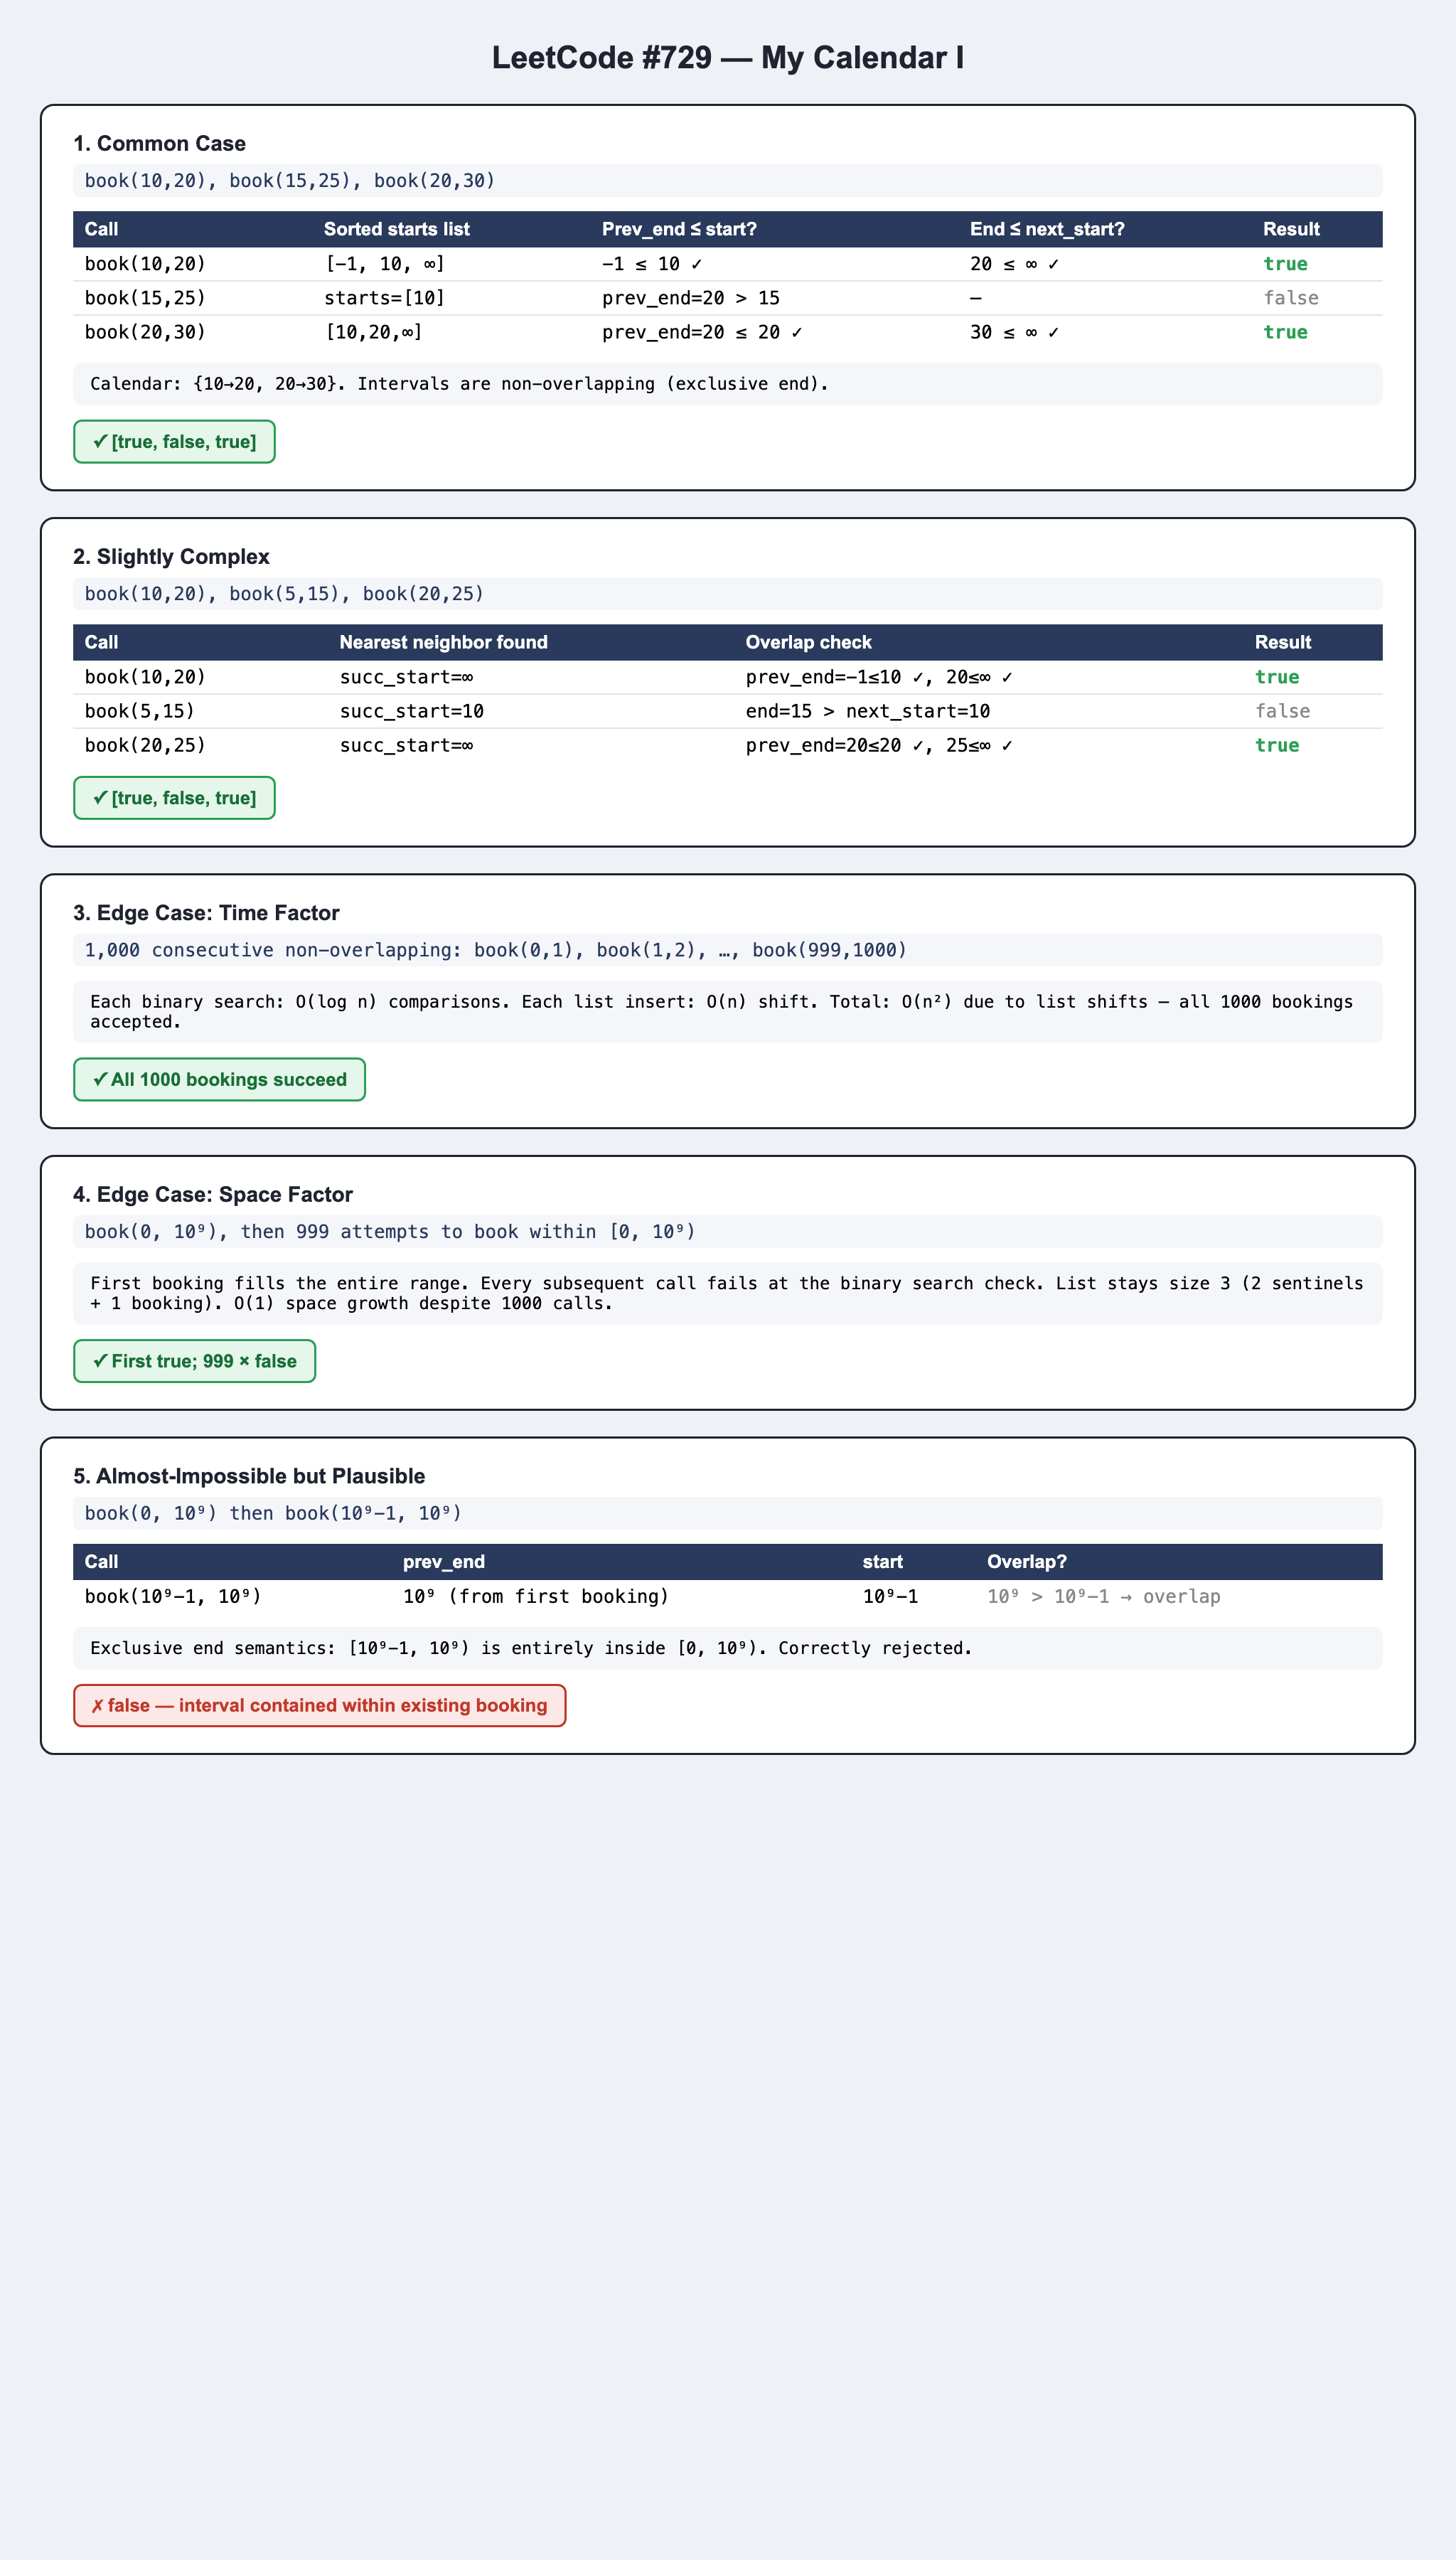